# Chapter 4 Solutions: Essential math

---

---


In [9]:
# Solutions Setup
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))


print('Solutions setup complete!')

Solutions setup complete!


In [4]:
def verify_quantum_state(psi, tol=1e-10):
    norm = np.linalg.norm(psi)
    is_valid = np.abs(norm - 1.0) < tol
    return is_valid, norm

psi = np.array([(1+2j), (2-1j), (1+1j), (0.5-0.5j)])
is_valid, norm = verify_quantum_state(psi)
print(f"Valid: {is_valid}, Norm: {norm:.4f}")
# Output: Valid: False, Norm: 3.3166

psi_normalized = psi / norm
print("psi_normalized:", psi_normalized)
print(f"Normalized: {verify_quantum_state(psi_normalized)[0]}")

Valid: False, Norm: 3.5355
psi_normalized: [0.28284271+0.56568542j 0.56568542-0.28284271j 0.28284271+0.28284271j
 0.14142136-0.14142136j]
Normalized: True


## Orthonormal basis

In [8]:
def check_orthonormal_basis(vectors, tol=1e-10):
    n = len(vectors)
    for i in range(n):
        # Check normalization
        if np.abs(np.linalg.norm(vectors[i]) - 1.0) > tol:
            return False
        # Check orthogonality
        for j in range(i+1, n):
            if np.abs(np.vdot(vectors[i], vectors[j])) > tol:
                return False
    return True

v0 = 0.5 * np.array([1, 1j, 1, 1j])
v1 = 0.5 * np.array([1, 1j, -1, -1j])
print(f"[v0, v1] Orthonormal?: {check_orthonormal_basis([v0, v1])}")
# Output: Orthonormal: True
# Yes, they can be extended to a complete basis.
# two more orthonormal vectors are:
v2 = (1/np.sqrt(2)) * np.array([1, -1j, 0, 0])
v3 = (1/np.sqrt(2)) * np.array([0, 0, 1, -1j])

print(f"[v0, v1, v2, v3] Orthonormal?: {check_orthonormal_basis([v0, v1, v2, v3])}")

[v0, v1] Orthonormal?: True
[v0, v1, v2, v3] Orthonormal?: True


## Gershgorin bounds

Gershgorin: [0, 4]
Actual: [0.0341, 3.9659]


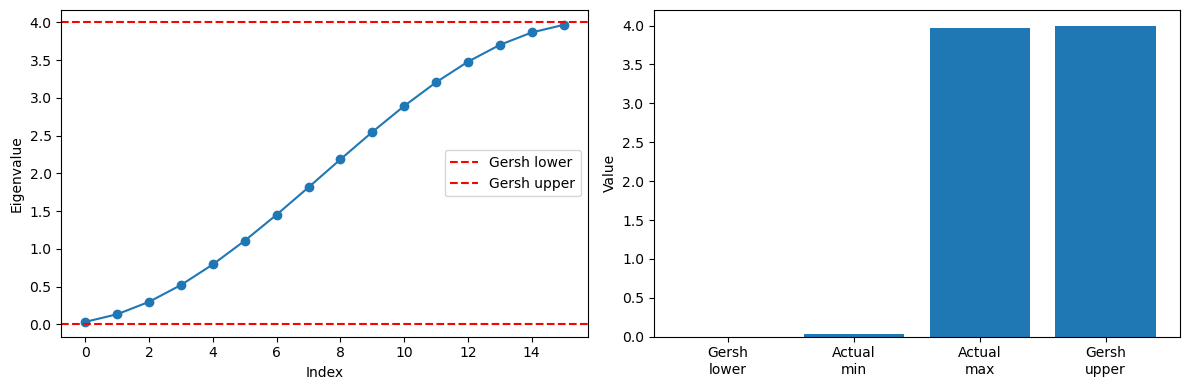

In [10]:


N = 16
values = [-np.ones(N-1), 2*np.ones(N), -np.ones(N-1)]
A = diags(values, [-1, 0, 1]).toarray()

eigenvalues = np.linalg.eigh(A)[0]
lambda_min, lambda_max = eigenvalues[0], eigenvalues[-1]

# Gershgorin bounds
gersh_lower, gersh_upper = 0, 4

print(f"Gershgorin: [{gersh_lower}, {gersh_upper}]")
print(f"Actual: [{lambda_min:.4f}, {lambda_max:.4f}]")

# Plot eigenvalue spectrum
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(N), eigenvalues, 'o-')
plt.axhline(gersh_lower, color='r', linestyle='--', label='Gersh lower')
plt.axhline(gersh_upper, color='r', linestyle='--', label='Gersh upper')
plt.xlabel('Index'); plt.ylabel('Eigenvalue'); plt.legend()

plt.subplot(1, 2, 2)
bounds = ['Gersh\nlower', 'Actual\nmin', 'Actual\nmax', 'Gersh\nupper']
values = [gersh_lower, lambda_min, lambda_max, gersh_upper]
plt.bar(bounds, values); plt.ylabel('Value')
plt.tight_layout(); plt.show()